In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [150]:
df_exercise = pd.read_csv('dataset/gym_members_exercise_tracking.csv')
df_met = pd.read_csv('dataset/met.csv')

In [151]:
df_exercise.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [152]:
df_met.head()

,Unnamed: 0,Actvitiy,Code,MET,Description
0,0,Bicycling,1004,16.0,"Bicycling, mountain, competitive racing"
1,1,Bicycling,1008,8.5,"Bicycling, BMX"
2,2,Bicycling,1009,8.5,"Bicycling, mountain, general"
3,3,Bicycling,1010,4.0,"Bicycling, <10 mph, leisure, to work or for pl..."
4,4,Bicycling,1011,6.8,"Bicycling, to/from work, self selected pace"


### Data Preprocessing

In [153]:
df_met.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1125 non-null   int64  
 1   Actvitiy     1125 non-null   object 
 2   Code         1125 non-null   int64  
 3   MET          1125 non-null   float64
 4   Description  1125 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 44.1+ KB


In [154]:
def set_workout_type(met):
    if met < 4.0:
        return 'Yoga'
    elif 4.0 <= met <= 6.0:
        return 'Strength'
    elif 6.0 < met <= 10.0:
        return 'Cardio'
    else:
        return 'HIIT'

df_met['Workout_Type'] = df_met['MET'].apply(set_workout_type)
df_met.rename(columns={'Actvitiy':'Activity'}, inplace=True)

df_met.head()

,Unnamed: 0,Activity,Code,MET,Description,Workout_Type
0,0,Bicycling,1004,16.0,"Bicycling, mountain, competitive racing",HIIT
1,1,Bicycling,1008,8.5,"Bicycling, BMX",Cardio
2,2,Bicycling,1009,8.5,"Bicycling, mountain, general",Cardio
3,3,Bicycling,1010,4.0,"Bicycling, <10 mph, leisure, to work or for pl...",Strength
4,4,Bicycling,1011,6.8,"Bicycling, to/from work, self selected pace",Cardio


In [155]:
remove_activities = [
    'Inactivity',
    'Sexual Activity',
    'Video Games',
    'Music Playing',
    'Religious Activities',
    'Volunteer Activities',
    'Self Care'
]

df_met = df_met[~df_met['Activity'].isin(remove_activities)]

In [156]:
df_met['Activity'] = df_met['Activity'].replace({'Home Activities' : 'House Chores', 'Home Repair' : 'House Chores', 'Lawn & Garden' : 'House Chores'})

In [157]:
df_merged_uncleaned = pd.merge(df_exercise, df_met, on='Workout_Type', how='inner', suffixes=('_ex','_met'))
df_merged = df_merged_uncleaned.drop(df_merged_uncleaned.columns[15], axis=1) #hapus kolom unnamed yg gak dipakai
df_merged['Workout_Type'] = df_merged['Workout_Type'].replace({'Yoga': 'Low Strength'})
df_merged.head()
df_merged.to_csv('merged_dataset.csv', index=False)

In [158]:
df_merged.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Activity,Code,MET,Description
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,3.5,4,3,30.2,Bicycling,1018,3.5,"Bicycling, leisure 5.5 mph"
1,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,3.5,4,3,30.2,Bicycling,1210,3.5,"Bicycling, stationary, 25-30 watts, very light..."
2,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,3.5,4,3,30.2,Bicycling,1262,2.3,"Bicycling, eccentric only, 100 to 149 W"
3,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,3.5,4,3,30.2,Conditioning Exercise,2022,3.8,"Calisthenics (e.g., pushups, sit ups, pull-ups..."
4,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,3.5,4,3,30.2,Conditioning Exercise,2024,2.8,"Calisthenics (e.g., curl ups, abdominal crunch..."


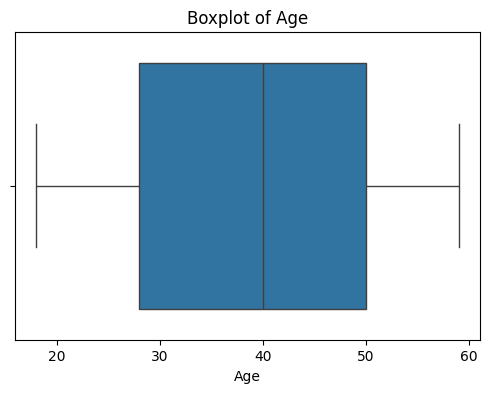

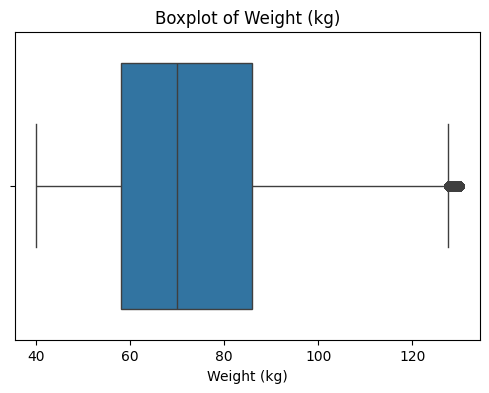

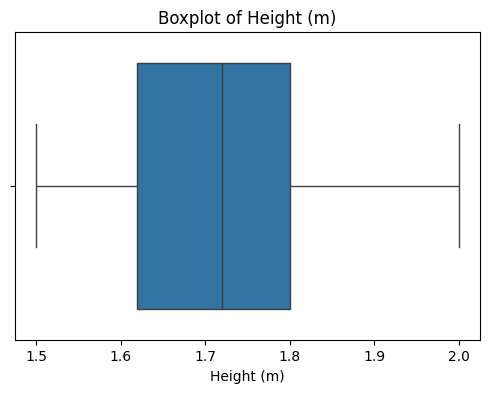

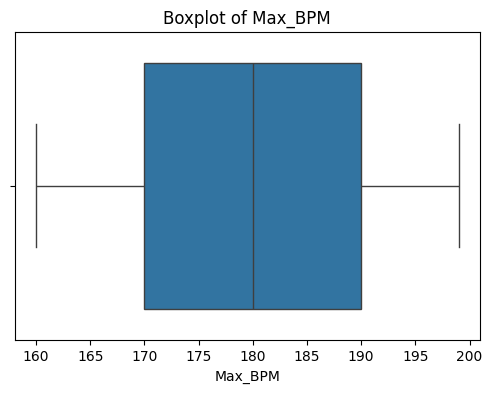

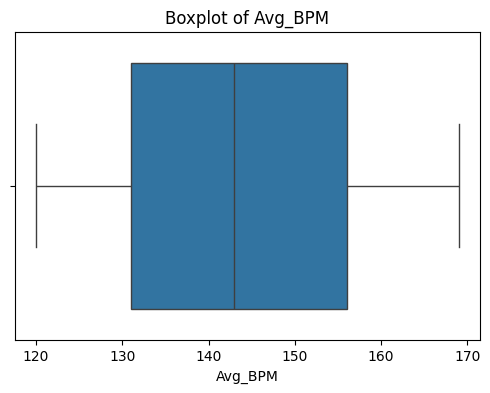

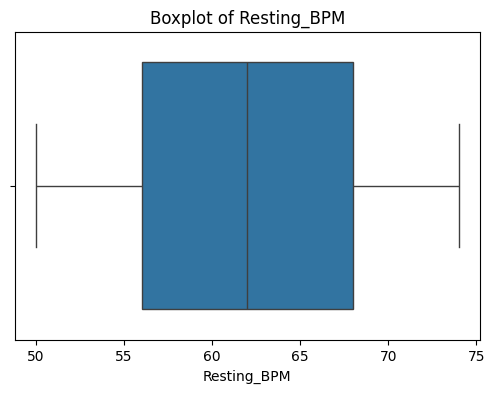

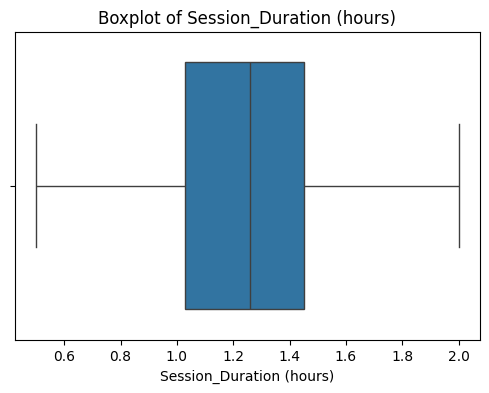

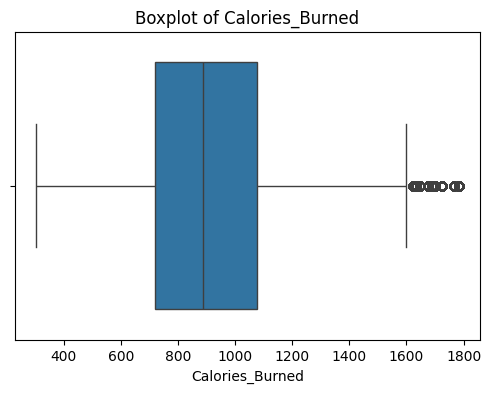

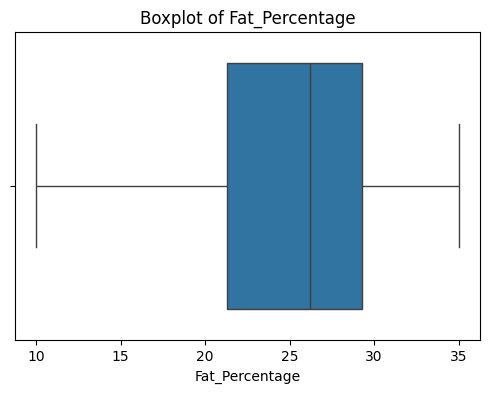

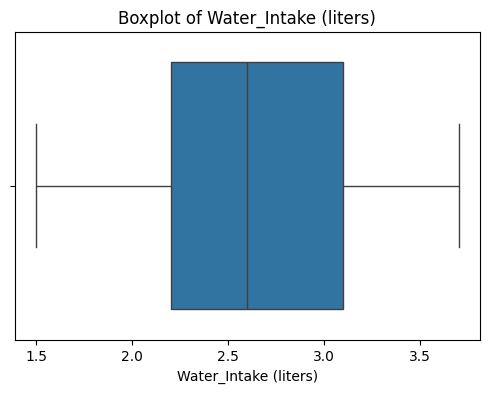

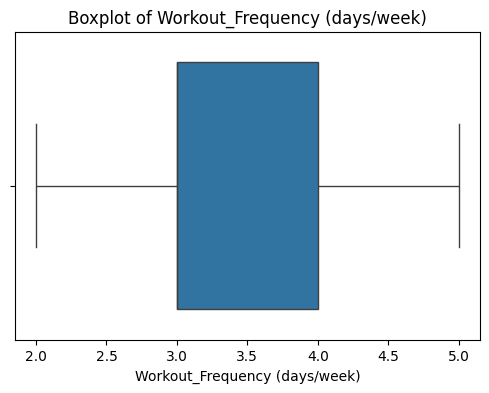

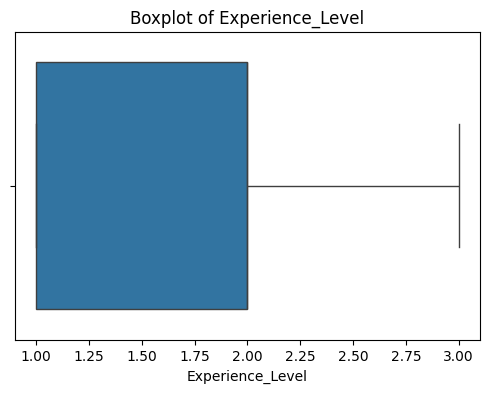

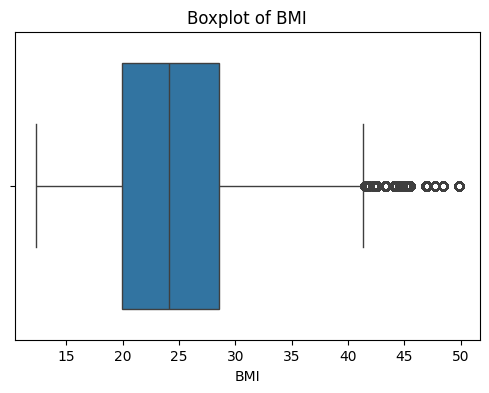

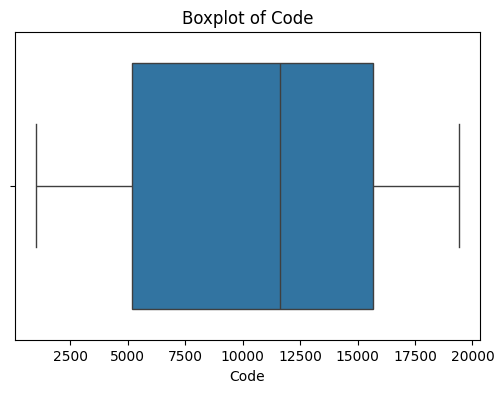

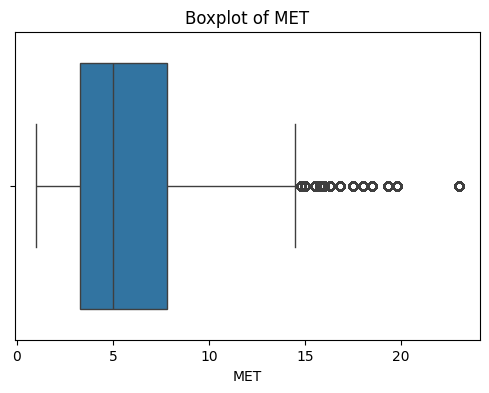

In [159]:
numeric_cols = df_merged.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_merged[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [160]:
def outlier_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

outliers = {}
for col in numeric_cols:
    outliers[col] = outlier_iqr(df_merged, col)
for col, outlier_df in outliers.items():
    print(f'Outliers in {col}:')
    print(outlier_df[[col]])
    print('\n')

Outliers in Age:
Empty DataFrame
Columns: [Age]
Index: []


Outliers in Weight (kg):
        Weight (kg)
23934         129.0
23935         129.0
23936         129.0
23937         129.0
23938         129.0
...             ...
224223        127.8
224224        127.8
224225        127.8
224226        127.8
224227        127.8

[2811 rows x 1 columns]


Outliers in Height (m):
Empty DataFrame
Columns: [Height (m)]
Index: []


Outliers in Max_BPM:
Empty DataFrame
Columns: [Max_BPM]
Index: []


Outliers in Avg_BPM:
Empty DataFrame
Columns: [Avg_BPM]
Index: []


Outliers in Resting_BPM:
Empty DataFrame
Columns: [Resting_BPM]
Index: []


Outliers in Session_Duration (hours):
Empty DataFrame
Columns: [Session_Duration (hours)]
Index: []


Outliers in Calories_Burned:
        Calories_Burned
22625            1688.0
22626            1688.0
22627            1688.0
22628            1688.0
22629            1688.0
...                 ...
235457           1783.0
235458           1783.0
235459         

In [161]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251297 entries, 0 to 251296
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Age                            251297 non-null  int64  
 1   Gender                         251297 non-null  object 
 2   Weight (kg)                    251297 non-null  float64
 3   Height (m)                     251297 non-null  float64
 4   Max_BPM                        251297 non-null  int64  
 5   Avg_BPM                        251297 non-null  int64  
 6   Resting_BPM                    251297 non-null  int64  
 7   Session_Duration (hours)       251297 non-null  float64
 8   Calories_Burned                251297 non-null  float64
 9   Workout_Type                   251297 non-null  object 
 10  Fat_Percentage                 251297 non-null  float64
 11  Water_Intake (liters)          251297 non-null  float64
 12  Workout_Frequency (days/week) 

In [162]:
df_merged.duplicated().sum()

np.int64(0)

In [163]:
df_merged.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
Activity                          object
Code                               int64
MET                              float64
Description                       object
dtype: object

In [164]:
df_merged['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [165]:
df_merged['Workout_Type'].value_counts()

Workout_Type
Low Strength    84128
Strength        73788
Cardio          65535
HIIT            27846
Name: count, dtype: int64

In [166]:
df_merged['MET'].describe()

count    251297.000000
mean          5.900015
std           3.423002
min           1.000000
25%           3.300000
50%           5.000000
75%           7.800000
max          23.000000
Name: MET, dtype: float64

In [167]:
df_met[df_met['MET'] == 23]

,Unnamed: 0,Activity,Code,MET,Description,Workout_Type
614,614,Running,12135,23.0,"Running, 14 mph (4.3 min/mile)",HIIT


In [168]:
df_merged['Activity'].unique()

array(['Bicycling', 'Conditioning Exercise', 'Dancing',
       'Fishing & Hunting', 'House Chores', 'Miscellaneous', 'Occupation',
       'Running', 'Sports', 'Transportation', 'Walking',
       'Water Activities', 'Winter Activities'], dtype=object)

In [169]:
encoder = OneHotEncoder(sparse_output=False)

df_merged_copied = df_merged.copy()
encoded = encoder.fit_transform(df_merged_copied[['Gender']])

df_merged_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Gender']))
df_merged = pd.concat([df_merged_copied.drop(['Gender'], axis=1), df_merged_encoded], axis=1)

df_merged_copied = df_merged.copy()
encoded = encoder.fit_transform(df_merged_copied[['Activity']])

df_merged_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Activity']))
df_merged = pd.concat([df_merged_copied.drop(['Activity'], axis=1), df_merged_encoded], axis=1)
df_merged.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,...,Activity_Fishing & Hunting,Activity_House Chores,Activity_Miscellaneous,Activity_Occupation,Activity_Running,Activity_Sports,Activity_Transportation,Activity_Walking,Activity_Water Activities,Activity_Winter Activities
0,56,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,56,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,56,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,56,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,56,88.3,1.71,180,157,60,1.69,1313.0,Low Strength,12.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [170]:
df_merged.dtypes


Age                                 int64
Weight (kg)                       float64
Height (m)                        float64
Max_BPM                             int64
Avg_BPM                             int64
Resting_BPM                         int64
Session_Duration (hours)          float64
Calories_Burned                   float64
Workout_Type                       object
Fat_Percentage                    float64
Water_Intake (liters)             float64
Workout_Frequency (days/week)       int64
Experience_Level                    int64
BMI                               float64
Code                                int64
MET                               float64
Description                        object
Gender_Female                     float64
Gender_Male                       float64
Activity_Bicycling                float64
Activity_Conditioning Exercise    float64
Activity_Dancing                  float64
Activity_Fishing & Hunting        float64
Activity_House Chores             

In [171]:
df_merged = df_merged.drop(df_merged.columns[[3, 4, 5, 7, 9, 10, 11, 12, 13, 14]], axis=1)
df_merged.dtypes

Age                                 int64
Weight (kg)                       float64
Height (m)                        float64
Session_Duration (hours)          float64
Workout_Type                       object
MET                               float64
Description                        object
Gender_Female                     float64
Gender_Male                       float64
Activity_Bicycling                float64
Activity_Conditioning Exercise    float64
Activity_Dancing                  float64
Activity_Fishing & Hunting        float64
Activity_House Chores             float64
Activity_Miscellaneous            float64
Activity_Occupation               float64
Activity_Running                  float64
Activity_Sports                   float64
Activity_Transportation           float64
Activity_Walking                  float64
Activity_Water Activities         float64
Activity_Winter Activities        float64
dtype: object

In [173]:
target_cols = ['Workout_Type', 'MET', 'Description']
feature_cols = [col for col in df_merged.columns if col not in target_cols]

X = df_merged[feature_cols]
y = df_merged[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Fitur (X):", X.columns.tolist())
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Fitur (X): ['Age', 'Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Gender_Female', 'Gender_Male', 'Activity_Bicycling', 'Activity_Conditioning Exercise', 'Activity_Dancing', 'Activity_Fishing & Hunting', 'Activity_House Chores', 'Activity_Miscellaneous', 'Activity_Occupation', 'Activity_Running', 'Activity_Sports', 'Activity_Transportation', 'Activity_Walking', 'Activity_Water Activities', 'Activity_Winter Activities']

X_train: (175907, 19), X_test: (75390, 19)
y_train: (175907, 3), y_test: (75390, 3)
